In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import fft

Variable initialization

In [2]:
M = 32 # signal dimension
N = 2 * M # number of atoms in the expansion

C = np.zeros((M, M)) # matrix containing the standard basis (a kronecker delta in each column)
DCT = np.zeros((M, M)) #matrix containing the DCT basis (a DCT function in each column)

Generate the 1D-DCT basis

In [3]:
for i in range(M):
    a = np.zeros(M)
    a[i] = 1
    DCT[:, i] = fft.idct(a, norm='ortho') 

Generating the 1-D canonical basis

In [ ]:
for i in range(M):
    a = np.zeros(M)
    a[i] = 1
    C[:, i] = a

Define the dictionary $D = [DCT, C]$

Text(0.5, 1.0, 'Our dictionary M = 32, N = 64')

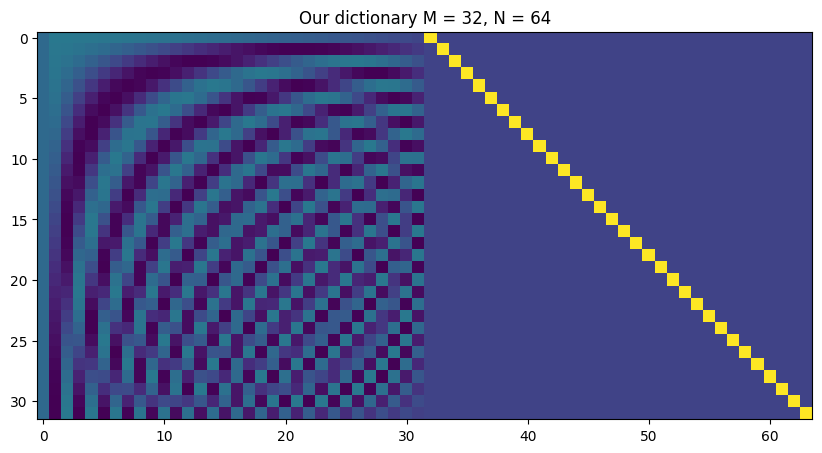

In [5]:
D = np.hstack((DCT, C))

plt.figure(figsize=(10,10))
plt.imshow(D)
plt.title(f'Our dictionary M = {M}, N = {N}')

Generate a signal that is sparse w.r.t. $D$
-----------------------------------------
To this purpose add a spike to the sum of few DCT atoms, i.e., add a spike to $\mathbf{s}$ that is sparse w.r.t. $C$. Bear in mind that the spike is to be considered a signal to be reconstructed, rather than noise

In [6]:
L = 4
sigma_noise = 0.2

Randomly define the coefficients of a sparse representation w.r.t. $DCT$ (make sure the nonzero coefficients are sufficiently large)

In [7]:
x0 = np.zeros(N)
indices = np.random.choice(M, L-1, replace=False)
x0[indices] = np.random.randn(L-1)

Choose spike location

In [8]:
spikeLocation = np.random.randint(M+1, N)
x0[spikeLocation] = 5

Synthetize the corresponding signal in the signal domain and add noise


In [9]:
s0 = D @ x0
s = s0 + sigma_noise * np.random.randn(M)

Plot the sparse signal

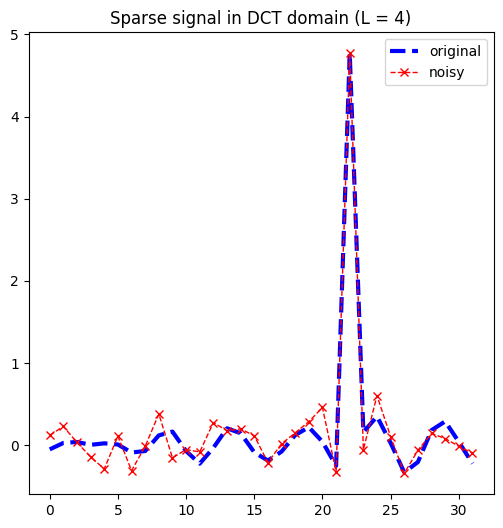

In [10]:
LN_WDT = 2
MRK_SZ = 10

plt.figure(figsize=(6, 6))
plt.plot(s0, 'b--', linewidth=LN_WDT+1)
plt.plot(s, 'r--x', linewidth=LN_WDT-1)
plt.title(f'Sparse signal in DCT domain (L = {L:.0f})')
plt.legend(['original', 'noisy'])

Orthogonal Matching Pursuit
---------------------------

Initialize all the variables, including the residual, namely the components of the signals that can not be represented (here the signal at the very beginning)

In [11]:
x_OMP = np.zeros(N)

# residual
r = s.copy()

# support set
omega = []

MINIMUM_NORM_RES = 0.1

OMP loop starts.

Stoppint criteria: continue until the sparsity of the representation reaches L

In [12]:
while np.count_nonzero(x_OMP) < L and np.linalg.norm(r, ord=2) > MINIMUM_NORM_RES: # no k < kmax because redundant
    # SWEEP STEP: look for the column of D that matches at best noisySignal
    # compute the residual w.r.t. each column of D
    e = np.zeros(N)
    for j in range(N):
        e[j] = (np.linalg.norm(r, ord=2) ** 2) - (r.T @ D[:, j]) ** 2

    # find the column of D that matches at best r
    jStar = np.argmin(e)

    # UPDATE the support set with the jStar coefficient
    if jStar not in omega:
        omega.append(jStar)
    else:
        break

    # update the coefficients by solving the least square problem min ||D_omega x - s ||
    D_omega = D[:, omega]
    # x = np.linalg.inv(D_omega.T @ D_omega) @ D_omega.T @ s
    x = np.linalg.solve(D_omega.T @ D_omega, D_omega.T @ s) # more efficient way
    x_OMP[omega] = x

    # update the residual
    r = s - D @ x_OMP

SYNTHESIS: reconstruct the signal, by inverting the transformation to reconstruct the signal

In [13]:
s_hat_OMP = D @ x_OMP

Show the result

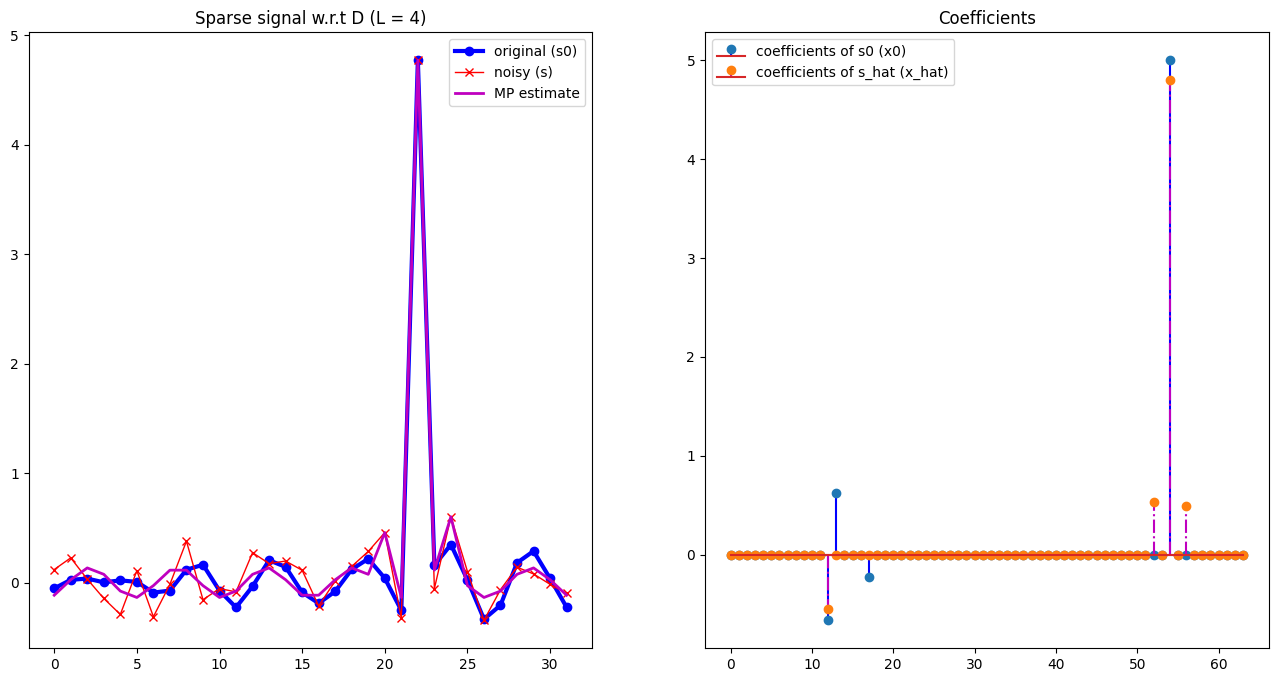

In [14]:
LN_WDT = 2
MRK_SZ = 10

fix, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].plot(s0, 'b-o', linewidth=LN_WDT + 1)
ax[0].plot(s, 'r-x', linewidth=LN_WDT - 1)
ax[0].plot(s_hat_OMP, 'm-', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal w.r.t D (L = {L:.0f})')
ax[0].legend(['original (s0)', 'noisy (s)', 'MP estimate'])

ax[1].stem(x0, linefmt='b-', markerfmt='C0o')
ax[1].stem(x_OMP, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('Coefficients')
ax[1].legend(['coefficients of s0 (x0)', 'coefficients of s_hat (x_hat)'])

Least Squares Orthogonal Matching Pursuit
-----------------------------------------

Initialize all the variables, including the residual, namely the components of the signals that can not be represented (here the signal at the very beginning)

In [15]:
x_LSOMP = np.zeros(N)

# residual
r = s.copy()

# support set
omega = []

MINIMUM_NORM_RES = 0.1

LSOMP loop starts.

Stoppint criteria: continue until the sparsity of the representation reaches L

In [16]:
while np.count_nonzero(x_LSOMP) < L and np.linalg.norm(r, ord=2) > MINIMUM_NORM_RES:
    # SWEEP STEP: find the best column by solving the LS problem
    if len(omega) == 0:
        # at the first iteration perform the usual sweep step
        e = np.zeros(N)
        r_norm_sq = np.linalg.norm(r, ord=2) ** 2
        for j in range(N):
            e[j] = r_norm_sq - (r.T @ D[:, j]) ** 2
    else:
        # perform the sweep step by solving the LS problem
        D_omega = D[:, omega]

        e = np.full(N, np.inf)

        # forall direction j not in \omega
        for j in range(N):
            if j in omega:
                continue

            dj = D[:, j]

            A = np.block([
                [D_omega.T @ D_omega, (D_omega.T @ dj)[:, None]],
                [(dj.T @ D_omega)[None, :], np.array([[dj.T @ dj]])]
            ])
            b = np.concatenate([
                D_omega.T @ s,
                np.array([dj.T @ s])
            ])

            sol = np.linalg.solve(A, b)
            z = sol[:-1] # z \in R^k where k = |omega|
            u = sol[-1] # u \in R

            # construct the vector xi with the solution of the LS problem: [z; u]
            xi = np.append(z, u)
            # alternatively, we can construct xi as follows:
            # xi = np.zeros(N)
            # xi[omega] = z
            # xi[j] = u

            # construct the matrix D_temp by adding the column dj to D_omega
            D_temp = np.column_stack((D_omega, dj))

            e[j] = np.linalg.norm(D_temp @ xi - s, ord=2) ** 2

    jStar = np.argmin(e)
    if jStar in omega:
        break

    # UPDATE the support set with the jStar coefficient
    omega.append(jStar)
    
    # update the coefficients
    D_omega = D[:, omega]
    x_omega = np.linalg.solve(D_omega.T @ D_omega, D_omega.T @ s)
    
    x_LSOMP = np.zeros(N)
    x_LSOMP[omega] = x_omega

    # update the residual
    r = s - D @ x_LSOMP

SYNTHESIS: reconstruct the signal, by inverting the transformation to reconstruct the signal

In [17]:
s_hat_LSOMP = D @ x_LSOMP

Show the result

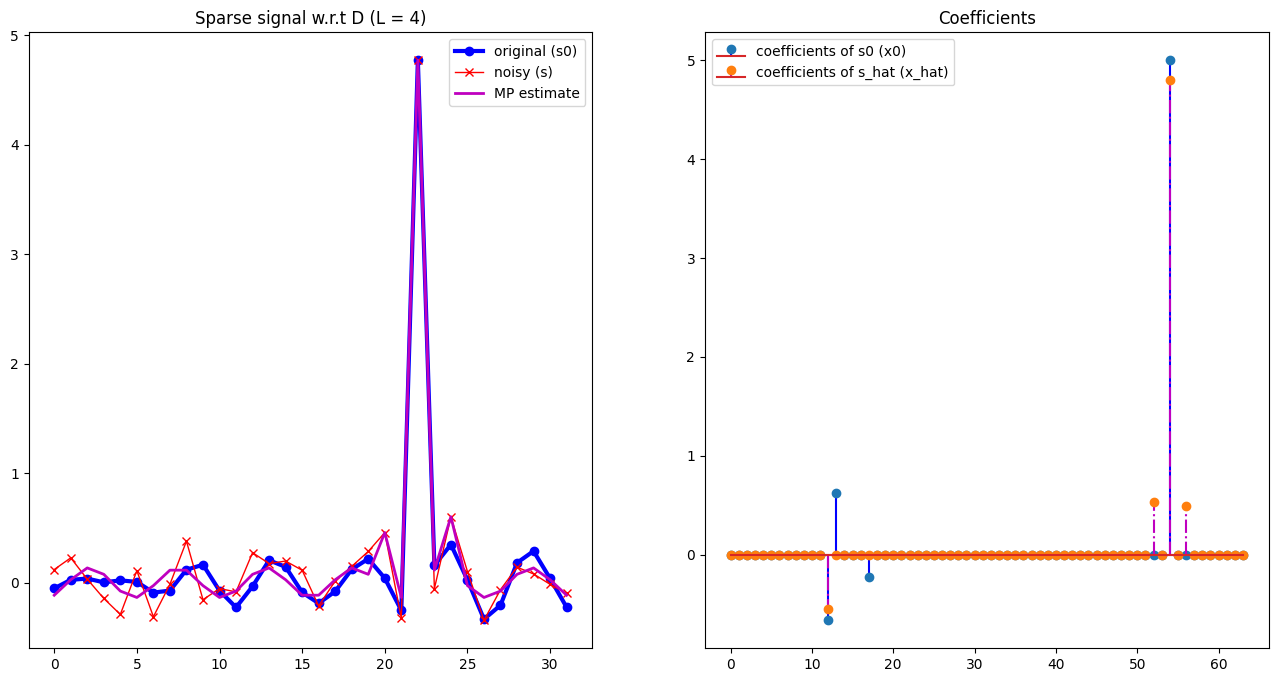

In [18]:
LN_WDT = 2
MRK_SZ = 10

fix, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].plot(s0, 'b-o', linewidth=LN_WDT + 1)
ax[0].plot(s, 'r-x', linewidth=LN_WDT - 1)
ax[0].plot(s_hat_LSOMP, 'm-', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal w.r.t D (L = {L:.0f})')
ax[0].legend(['original (s0)', 'noisy (s)', 'MP estimate'])

ax[1].stem(x0, linefmt='b-', markerfmt='C0o')
ax[1].stem(x_LSOMP, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('Coefficients')
ax[1].legend(['coefficients of s0 (x0)', 'coefficients of s_hat (x_hat)'])